In [3]:
#!/usr/bin/env python3
"""
main.py
=======
Entry point and configuration hub for the UNO-card symbol-candidate
preprocessing pipeline.

Usage:
    python main.py

Pipeline:
    1. Load image(s) from IMAGE_SOURCE            (io_utils.load_images_from)
       -- IMAGE_SOURCE may be a directory OR a single image file.
    2. Run the preprocessing chain on the batch   (preprocess_utils.preprocess_image)
       threshold -> morphology -> edges -> tile_image
                 -> remove_noise_contours -> tile_selection
    3. Persist the resulting symbol_candidates    (io_utils.save_images_to)
"""

from __future__ import annotations

from typing import Any, Dict

from io_utils import load_images_from, save_images_to
from preprocess_utils import preprocess_image


# ============================================================================
# CONFIGURATION
# ============================================================================

# ---- I/O ----
# IMAGE_SOURCE may be either a directory (batch mode) or a single image file
# (single-image mode). When it's a directory, IMAGE_GLOB filters its contents;
# when it's a file, IMAGE_GLOB is ignored.
IMAGE_SOURCE = "./data/train_images/L1000774.jpg"   # single-image mode
#IMAGE_SOURCE = "./data/reference_images"              # batch mode
OUTPUT_DIR  = "./tile"                              # candidate tiles go here
IMAGE_GLOB  = "*.jpg"                               # used only in batch mode
SAVE_FORMAT = "png"                                 # extension for saved tiles

# ---- diagnostics ----
SHOW_PLOTS = True   # master toggle: True renders every stage's matplotlib
                    # figure for every image; False runs silently.

# ---- thresholding (HSV white-bg filter) ----
SAT_MAX = 40        # HSV saturation below this -> candidate background
VAL_MIN = 180       # HSV value above this      -> candidate background

# ---- morphology / mask cleanup ----
MEDIAN_KSIZE  = 3   # 0 to skip
OPEN_KSIZE    = 3   # 0 to skip
CLOSE_KSIZE   = 3   # 0 to skip
MIN_BLOB_AREA = 20  # 0 to skip
SMOOTH_KSIZE  = 5   # Gaussian-then-rethreshold contour smoothing; 0 to skip

# ---- edges ----
SOBEL_KSIZE = 3

# ---- tiling geometry ----
TILE_SIZE = 99        # square window in px
OVERLAP   = 2.0 / 3.0 # fractional overlap -> stride = round(TILE_SIZE * (1 - OVERLAP))

# ---- noise removal (per-tile contour cleanup, contour_utils) ----
# After tiling, every tile is cleaned by remove_noise_contours: contours that
# are too small, or clipped by the tile frame, are dropped before selection.
NOISE_MIN_PIXELS  = 70   # drop contours with fewer than this many pixels
NOISE_EDGE_MARGIN = 2     # drop contours within this many px of a tile edge
# NOISE_FG_THRESHOLD: intensity above which a tile pixel counts as "foreground"
# for contour labeling. Left unset here -> preprocess_image defaults it to
# EDGE_THRESH, so the noise step and tile selection agree on what an edge pixel
# is. To override, add e.g. fg_threshold=30 to PIPELINE_KW below.

# ---- tile selection ----
EDGE_THRESH    = 20   # pixel intensity above which a Sobel pixel is "edge"
EDGE_KEEP_FRAC = 0.03 # keep tile when edge-pixel fraction >= this

# ---- reproducibility ----
SEED = 42


# Bundle the stage overrides we want preprocess_image to use.
# Keys must be parameter names accepted by preprocess_image (see _STAGE_PARAMS
# in preprocess_utils); an unrecognised key now raises TypeError instead of
# being silently ignored.
PIPELINE_KW: Dict[str, Any] = dict(
    sat_max=SAT_MAX, val_min=VAL_MIN,
    median_ksize=MEDIAN_KSIZE, open_ksize=OPEN_KSIZE,
    close_ksize=CLOSE_KSIZE, min_blob_area=MIN_BLOB_AREA,
    smooth_ksize=SMOOTH_KSIZE,
    ksize=SOBEL_KSIZE,
    tile_size=TILE_SIZE, overlap=OVERLAP,
    min_pixels=NOISE_MIN_PIXELS, edge_margin=NOISE_EDGE_MARGIN,
    edge_thresh=EDGE_THRESH, edge_keep_frac=EDGE_KEEP_FRAC,
    seed=SEED,
)


loaded 1 image(s) from ./data/train_images/L1000774.jpg

=== preprocess_image: L1000774 ===


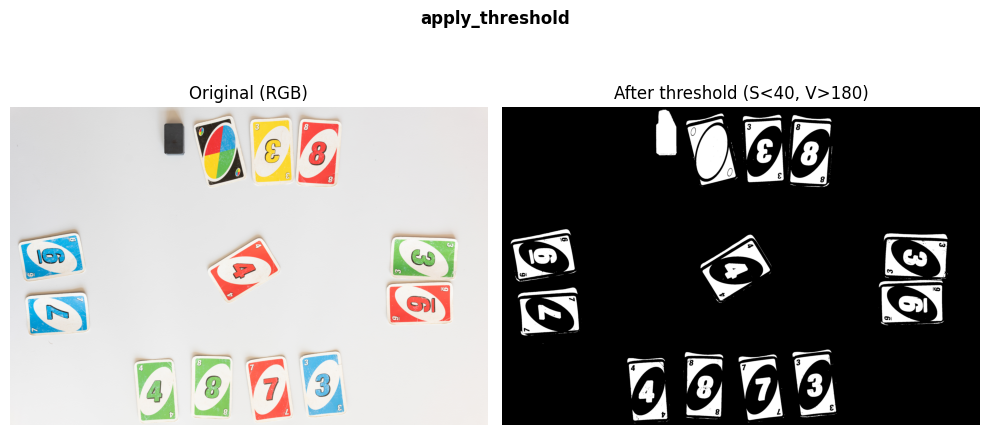

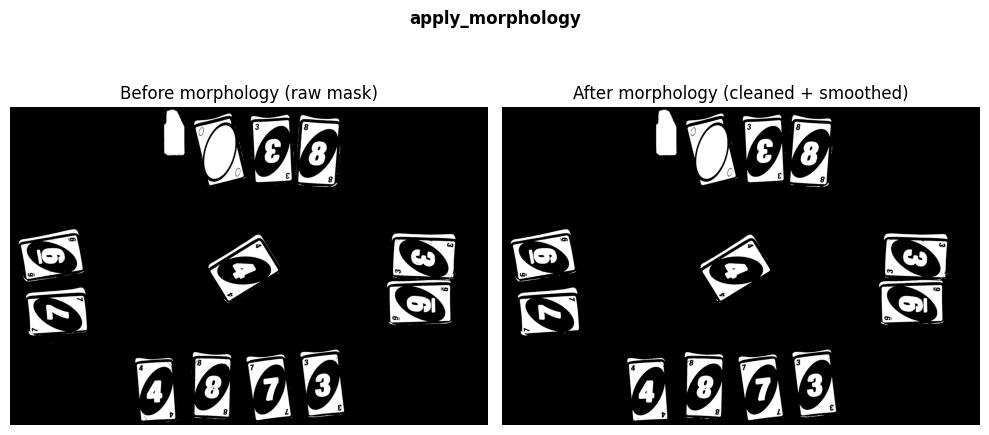

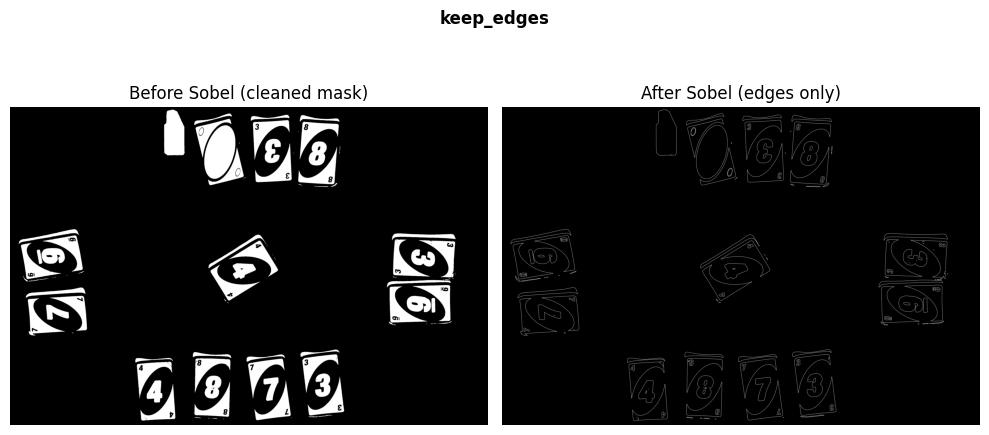

tile_selection
--------------------------------------------------
  parameters    : edge_thresh=20, edge_keep_frac=3.00%
  geometry      : 120 cols x 79 rows = 9480 tiles (tile 99px, stride 33px)
  result        : kept 74 / discarded 9406 (keep ratio 0.008)
  kept edge-frac: min=0.031 mean=0.049 max=0.081
--------------------------------------------------


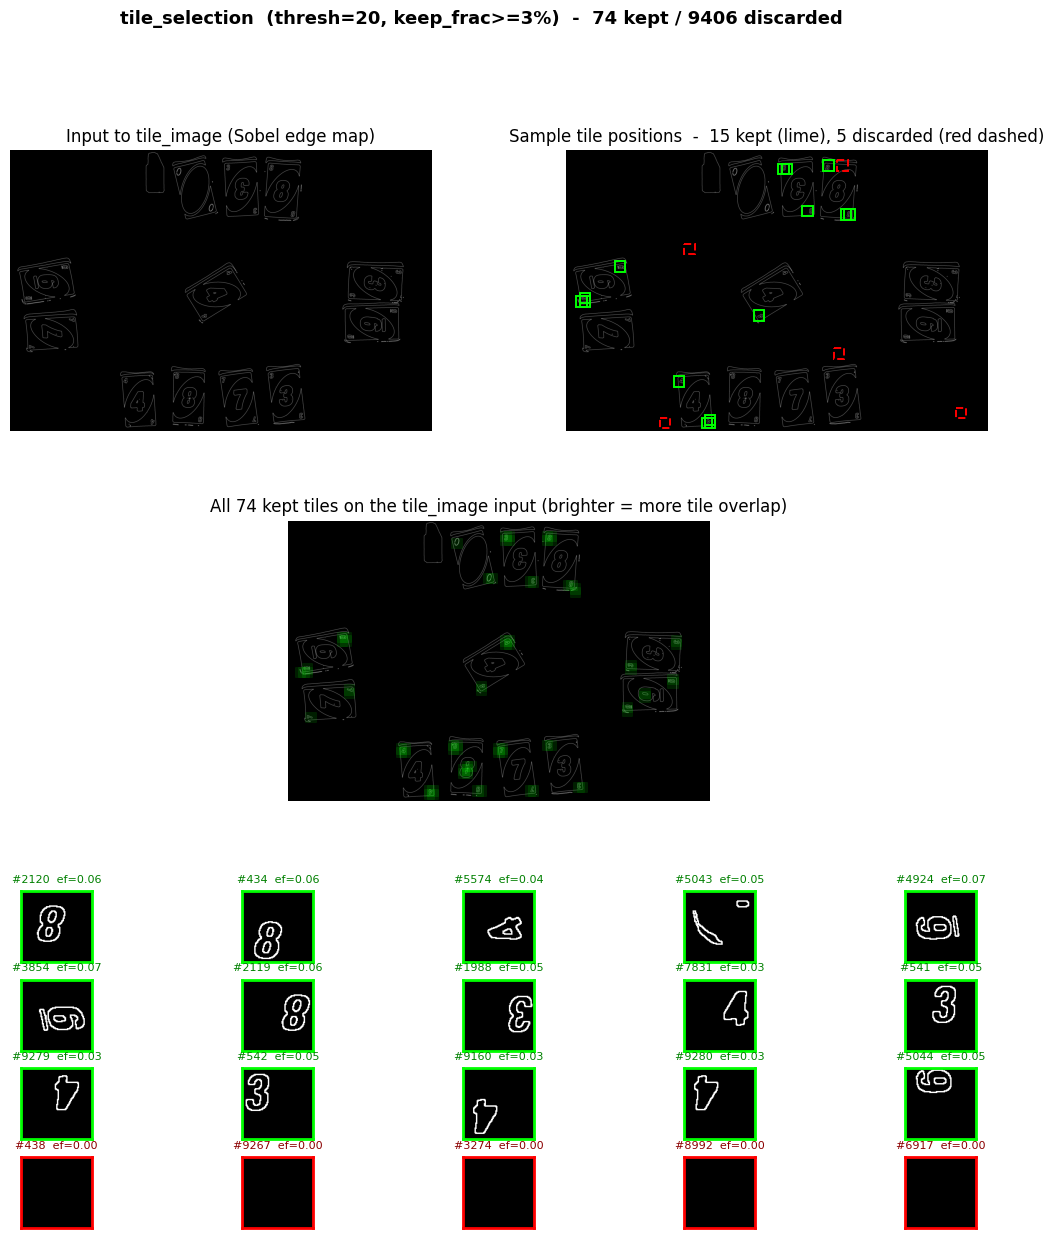

rotation_translation_correction
--------------------------------------------------
  parameters    : fg_threshold=20, max_iter=15, tol=0.5
  rectified     : 74 candidate tile(s)
  translation   : mean |offset| = 20.51 px (max 34.55 px)
  rotation      : mean |angle|  = 35.34 deg (max 89.32 deg)
--------------------------------------------------


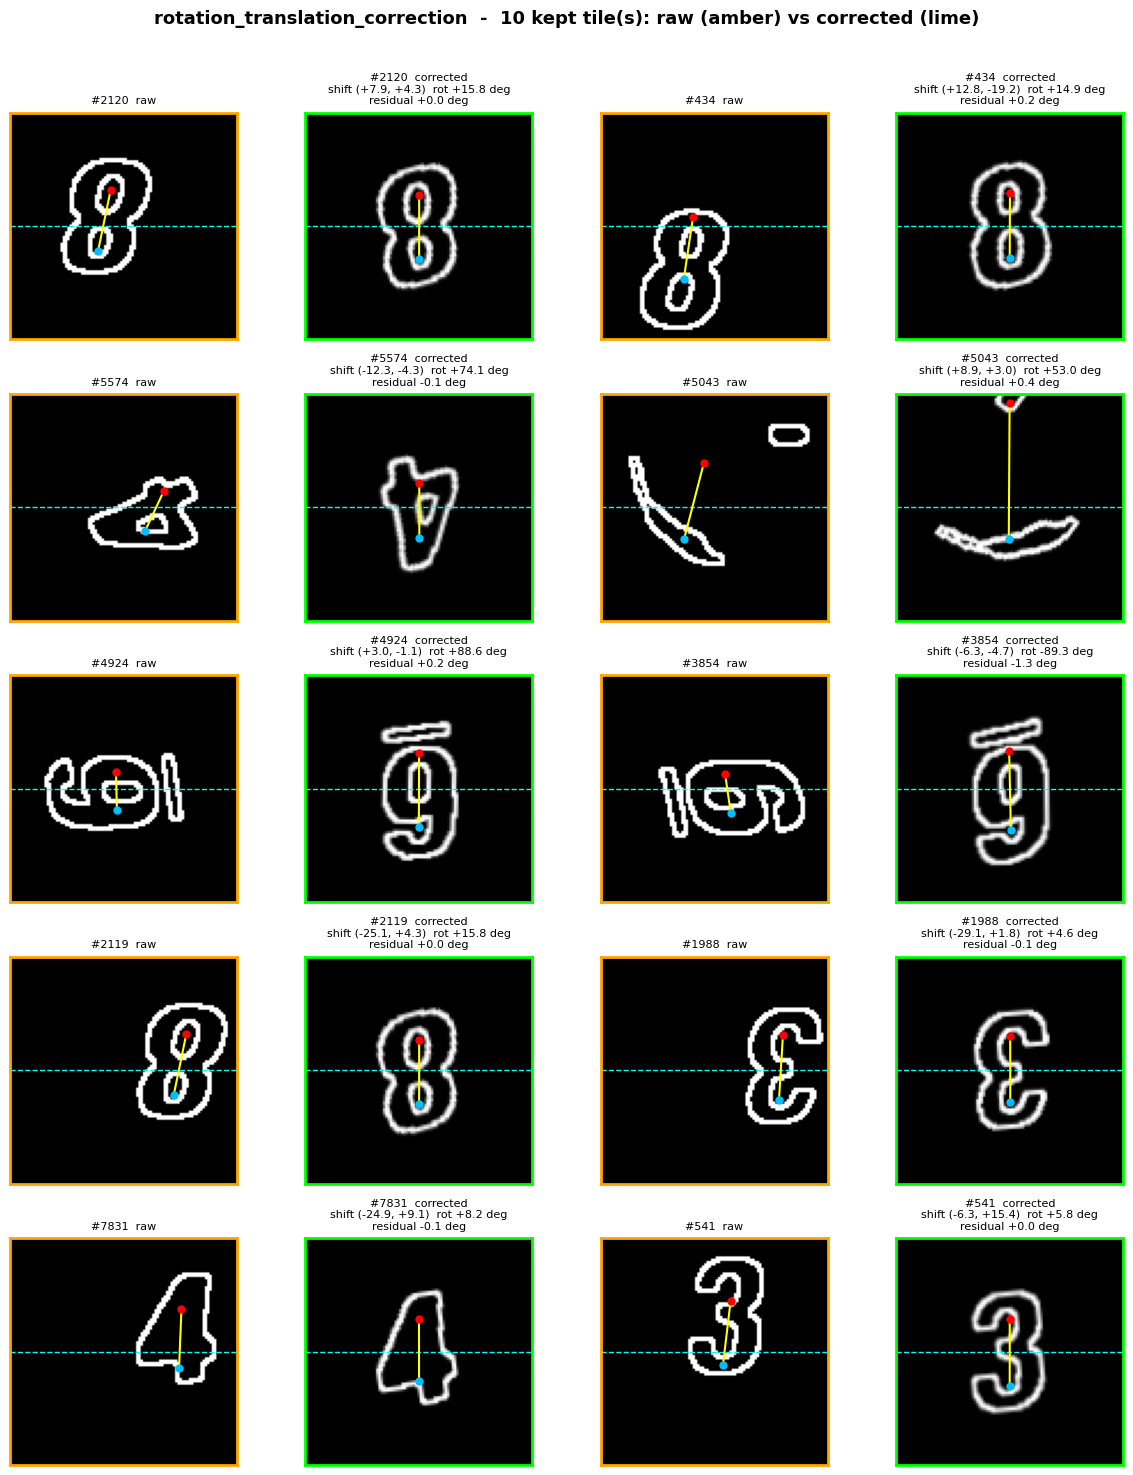


=== save phase ===
saved 74 candidate tile(s) to ./tile\L1000774/

Done. 74 candidate tile(s) across 1 image(s).


In [4]:
images = load_images_from(IMAGE_SOURCE, IMAGE_GLOB)

results = preprocess_image(images, show_plots=SHOW_PLOTS, **PIPELINE_KW)
# cards = read_cards(images)
# symbol = classifer(results)
# game state = attribute symbols to cards(s)
# export (csv)

print("\n=== save phase ===")
for filename, symbol_candidates in results.items():
    save_images_to(OUTPUT_DIR, filename, symbol_candidates,
                    fmt=SAVE_FORMAT)

total = sum(len(v) for v in results.values())
print(f"\nDone. {total} candidate tile(s) across {len(results)} image(s).")